In [8]:
import csv
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from time import sleep
from collections import deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv, LruPolicy
    from LabUserRequest import UserRequestEvents
    from LabEnvWrapper import EnvWrapper

import os
import sys

sources_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if sources_path not in sys.path:
    sys.path.append(sources_path)

import Common.config as config
import Common.datatypes as datatypes
import Common.utils as utils

import importlib

importlib.reload(config)
importlib.reload(datatypes)
importlib.reload(utils)

<module 'Common.utils' from 'c:\\Users\\es25591\\Workspace\\CacheVideoPredict360\\Sources\\Common\\utils.py'>

In [9]:
cfg = config.Config()

cfg.filename = f"lru_c{int(cfg.cache_capacity/1e9)}GB_ar{int(cfg.arrival_rate)}_z{cfg.zipf_alpha}.csv"
cfg.n_episodes = 10

In [ ]:
if __name__ == "__main__":

    du_caches = []

    mec_cache = CacheEngineEnv(
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n_gops=cfg.n_gops,
        cache_capacity=cfg.cache_capacity,
        policy=LruPolicy(
            max_size=cfg.cache_capacity,
            max_videos=cfg.cache_size
        )
    )

    # Initialize User Environment
    users_env = UserRequestEvents(
        n_nodes=cfg.n_nodes,
        n_users=cfg.n_users,
        n_videos=cfg.n_videos,
        n_gops=cfg.n_gops,
        n_layers=cfg.n_layers,
        n_tiles=cfg.n_tiles,
        n=cfg.n,
        users_viewport_tiles=None,
        requested_videos=None,
        users_arrivals=None,
        arrival_rate=cfg.arrival_rate,
        zipf_alpha=cfg.zipf_alpha,
    )

    # Create latency model (replace numbers with your real config)
    P = cfg.n_nodes; max_U = cfg.n_users
    lat_model = MultiDULatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,   # 640 Mbps -> 80e6 B/s
        R_C_M=125e6, # 1 Gbps -> 125e6 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,    # 1 ms
        mec_fixed_delay=0.005,   # 5 ms
        cloud_fixed_delay=0.1   # 100 ms
    )

    def prefetch_fn(cache, action):
        return cache.lru_live_prefetching(action)
    
    def reward_fn(env, reqs):
        return env.avg_psnr_reward(reqs)

    env = EnvWrapper(
        n=cfg.n,
        m=cfg.m,
        n_layers=cfg.n_layers,
        users_env=users_env, 
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=lat_model,
        theta=cfg.theta,
        lam=cfg.lam,
        max_steps=cfg.max_steps,
        prefetch_fn=prefetch_fn,
        reward_fn=reward_fn
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {cfg.n_users}\n"
        f"Cache capacity: {int(cfg.cache_capacity)}\n"
        f"Max videos: {cfg.cache_size}\n"
        f"Video matrix: {cfg.n_videos}x{cfg.n_layers}x{cfg.n*cfg.m}\n"
        f"==============================\n"
    )

    results = []
    scores = []
    active_users_log = []  # Track active users per step

    for ep in range(cfg.n_episodes):

        obs, info = env.reset()

        cache_hits = 0
        cache_misses = 0
        soft_hits = 0.0
        total_reward = 0.0
        avg_psnr = []

        for step in count():

            reqs = info['users_requests']
            
            actions = []
            action_taken = False

            for req in reqs:
                u = req["u"]
                v = req["video"]
                g = req["gop"]
                tiles = req["tiles"]
                viewport = req["viewport"]
                base_req_init = req["base_req_init"]

                has_base_layer = any(
                    t.get("events", {}).get("alpha_M_u") == 1 for t in tiles
                )

                if g == 0 and not has_base_layer:
                    actions.append({
                        'gop': g,
                        'video': v,
                        'tiles': viewport,
                        'base_req_init': base_req_init
                    })
                elif has_base_layer:
                    actions.append({
                        'gop': g,
                        'video': v,
                        'tiles': viewport,
                        'base_req_init': True
                    })
                else:
                    actions.append(None)

            # --- STEP ENV ---
            obs, reward, done, info = env.step(actions)

            if done:
                break

            reward_delta, hits_delta, misses_delta, _ = utils.update_metrics(info, reward)
            total_reward += reward_delta
            cache_hits += hits_delta
            cache_misses += misses_delta

        utils.save_training_results(
            path_=cfg.path_results,
            filename=cfg.filename,
            ep=ep,
            total_reward=total_reward,
            cache_hits=cache_hits,
            cache_misses=cache_misses,
            soft_hits=soft_hits,
            agent=None
        )

        print(f"--- Episode {ep} completed. Total Reward: {total_reward:.2f}, Cache Hits: {cache_hits}, Cache Misses: {cache_misses}, Total Requests: {len(env.total_gop_requests_per_user)} ---")

Experiment ===================
Total users: 400
Cache capacity: 10500000000
Video matrix: 500x2x12

--- Episode 0 completed. Total Reward: 47814.11, Cache Hits: 310553, Cache Misses: 29175, Total Requests: 400 ---
--- Episode 1 completed. Total Reward: 48545.38, Cache Hits: 301110, Cache Misses: 23930, Total Requests: 400 ---


KeyboardInterrupt: 

Loading data from: c:\Users\es25591\Workspace\CacheVideoPredict360\Results/lru_c10GB_ar20_z0.8.csv


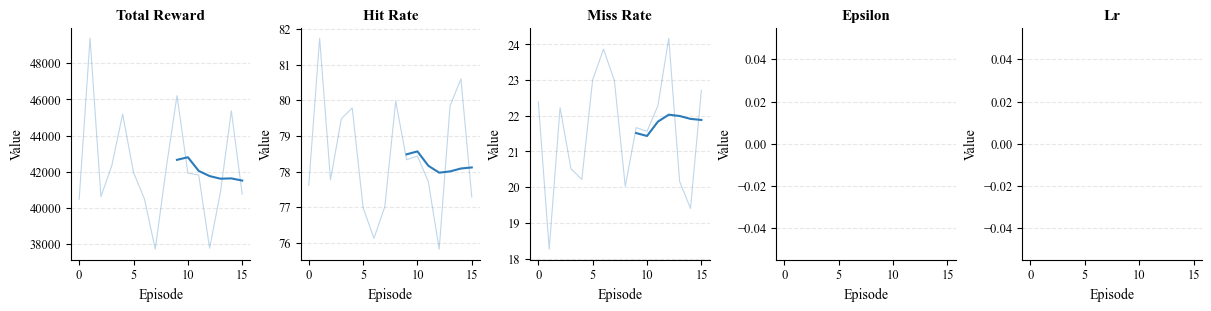

In [ ]:
# ----------------------------------------------------------------      
# 1. Publication Style Configuration
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True
})

# Professional color for line plots
PRIMARY_COLOR = "#2b7bba"

# ----------------------------------------------------------------
# 2. Data Loading & Smoothing
# ----------------------------------------------------------------
path = cfg.path_results + "/" + cfg.filename

print(f"Loading data from: {path}")

df = pd.read_csv(path)

total = (df["cache_hits"] + df["cache_misses"]).replace(0, np.nan)
df["hit_rate"] = (df["cache_hits"] / total) * 100
df["miss_rate"] = (df["cache_misses"] / total) * 100

# Metrics to plot
metrics = ["total_reward", "hit_rate", "miss_rate", "epsilon", "lr"]
window_size = 10  # Adjust smoothing window as needed

# ----------------------------------------------------------------
# 3. Plotting logic
# ----------------------------------------------------------------
# Adjusted figsize for a 4-column row (standard for full-width paper figures)
fig, axes = plt.subplots(1, len(metrics), figsize=(12, 3), sharex=True)

for ax, col in zip(axes, metrics):
    # Plot raw data with transparency (alpha)
    ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, alpha=0.3, linewidth=0.8, label='Raw')
    
    # Plot moving average for clearer trend (except for epsilon which is usually linear)
    if col != "epsilon":
        smoothed = df[col].rolling(window=window_size).mean()
        ax.plot(df["episode"], smoothed, color=PRIMARY_COLOR, linewidth=1.5, label='Trend')
    else:
        # Just a solid line for Epsilon
        ax.plot(df["episode"], df[col], color=PRIMARY_COLOR, linewidth=1.5)

    # Stylistic cleanup
    ax.set_title(col.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("Episode")
    
    # Remove redundant Y-labels to save space, or keep for clarity
    ax.set_ylabel("Value") 
    
    series = df[col].dropna()
    if not series.empty:
        ymin = series.min()
        ymax = series.max()
        pad = (ymax - ymin) * 0.05 if ymax != ymin else 1.0
        ax.set_ylim(ymin - pad, ymax + pad)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Tufte-style: remove top/right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Optional: Add a single legend to the first plot if needed
# axes[0].legend(frameon=False)

plt.show()
fig.savefig("drl_caching_metrics.png", dpi=300)

C:\Users\es25591\AppData\Local\Temp\ipykernel_36684\3657158268.py:17: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
C:\Users\es25591\AppData\Local\Temp\ipykernel_36684\3657158268.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
C:\Users\es25591\AppData\Local\Temp\ipykernel_36684\3657158268.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(bottom=0)


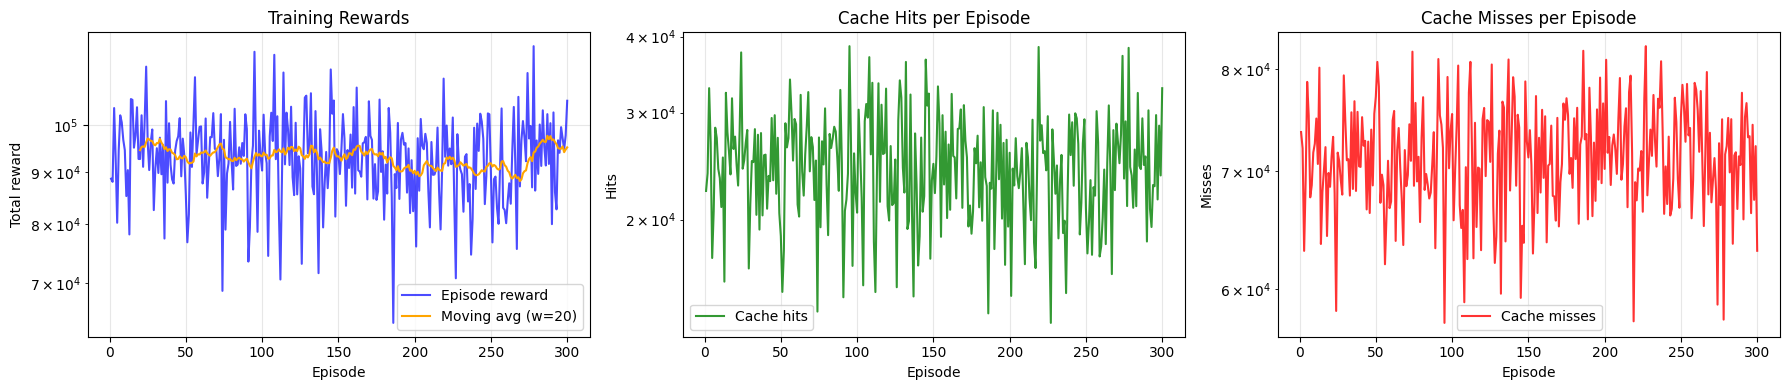

In [ ]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# 1. Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_yscale('log') 
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_yscale('log') 
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_yscale('log')
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

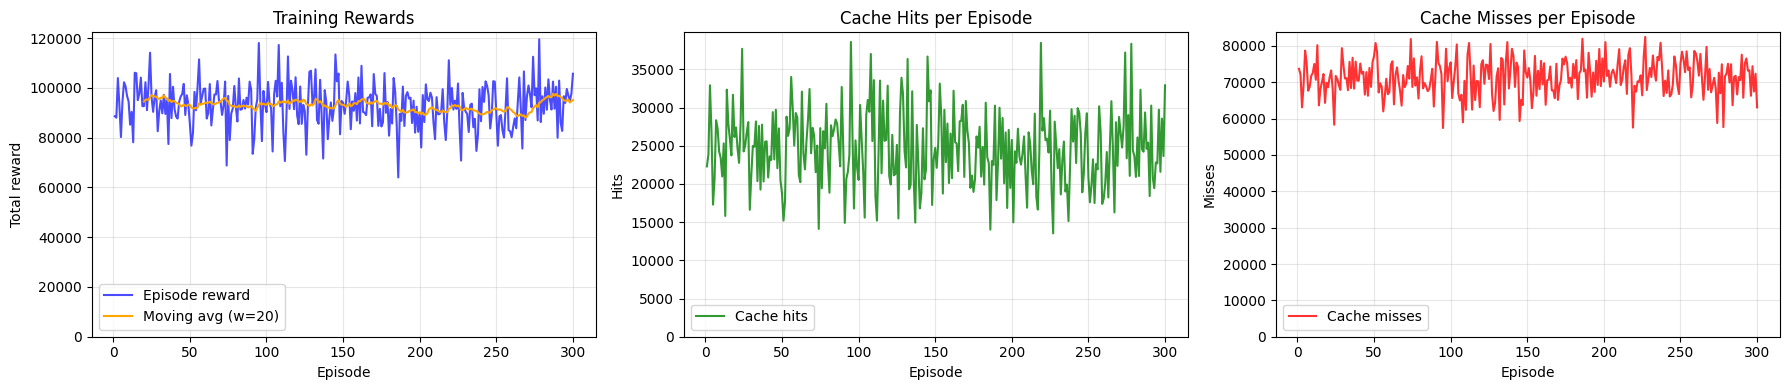

In [ ]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
        ]
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses = read_results(csv_path)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]
    base_totals = [h + m for h, m in zip(base_hits, base_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]
    base_hit_rate = [safe_pct(h, t) for h, t in zip(base_hits, base_totals)]
    base_miss_rate = [safe_pct(m, t) for m, t in zip(base_misses, base_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)
    base_ylim = (0, 100)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="Enhanced hit rate (%)", color="blue", alpha=0.9)
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="Enhanced miss rate (%)", color="red", alpha=0.9)
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Base Layer: Hit rate
    axes[1, 0].plot(episodes, base_hit_rate, label="Base hit rate (%)", color="green", alpha=0.9)
    axes[1, 0].set_title("Base Layer Hit Rate")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Rate (%)")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Base Layer: Miss rate
    axes[1, 1].plot(episodes, base_miss_rate, label="Base miss rate (%)", color="orange", alpha=0.9)
    axes[1, 1].set_title("Base Layer Miss Rate")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Rate (%)")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    # csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap150MB_eps0.05_2.csv'
    csv_filepath += '/fov_predictor_U500_V1000_G60_L2_N4_cap300MB_eps0.05_2.csv'
    
    #out_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap150MB_eps0.05_2.png'
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )


FileNotFoundError: CSV file not found: /home/eduardo/Workspace/CacheVideoPredict360/Results/fov_predictor_U500_V1000_G60_L2_N4_cap300MB_eps0.05_2.csv

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
        ]
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses = read_results(csv_path)

    # Compute shared y-lims per layer type
    def compute_ylim(a, b, pad=0.05, min_top=1.0):
        top = max(max(a or [0.0]), max(b or [0.0]))
        top = max(min_top, top)
        return (0, top * (1 + pad))

    enh_ylim = compute_ylim(enhanced_hits, enhanced_misses)
    base_ylim = compute_ylim(base_hits, base_misses)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Enhanced Layer Cache Hits
    axes[0, 0].plot(episodes, enhanced_hits, label="Enhanced layer hits", color="blue", alpha=0.8)
    axes[0, 0].set_title("Enhanced Layer Cache Hits per Episode")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Hits")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Plot 2: Enhanced Layer Cache Misses
    axes[0, 1].plot(episodes, enhanced_misses, label="Enhanced layer misses", color="red", alpha=0.8)
    axes[0, 1].set_title("Enhanced Layer Cache Misses per Episode")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Misses")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Plot 3: Base Layer Cache Hits
    axes[1, 0].plot(episodes, base_hits, label="Base layer hits", color="green", alpha=0.8)
    axes[1, 0].set_title("Base Layer Cache Hits per Episode")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Hits")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Plot 4: Base Layer Cache Misses
    axes[1, 1].plot(episodes, base_misses, label="Base layer misses", color="orange", alpha=0.8)
    axes[1, 1].set_title("Base Layer Cache Misses per Episode")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Misses")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2.csv'
    
    out_path = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U500_V1000_G60_L2_N4_cap100MB_eps0.05_2_layers.png'

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )
